<a href="https://colab.research.google.com/github/Ghalaahmed/Algorithm-Analysis-and-Design/blob/main/CSC301_Phishing_DetectionFinal.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Phishing Website Detection
## Decision Tree vs Logistic Regression

This notebook implements a phishing website detection system using two machine learning algorithms: **Decision Tree** and **Logistic Regression**.

The goal is to classify websites as phishing or legitimate based on extracted website features.
Both algorithms are trained on the same dataset and compared in terms of accuracy and execution time.

The execution time is reported in **milliseconds**, and the experiments are repeated using **different random samples** to calculate the average running time.

## 1. Import Libraries

In [29]:
import pandas as pd
import time
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

## 2. Load Dataset

In [30]:
df = pd.read_csv("phishing.csv")
print("Dataset shape:", df.shape)
df.head()

Dataset shape: (11054, 32)


,Index,UsingIP,LongURL,ShortURL,Symbol@,Redirecting//,PrefixSuffix-,SubDomains,HTTPS,DomainRegLen,...,UsingPopupWindow,IframeRedirection,AgeofDomain,DNSRecording,WebsiteTraffic,PageRank,GoogleIndex,LinksPointingToPage,StatsReport,class
0,0,1,1,1,1,1,-1,0,1,-1,...,1,1,-1,-1,0,-1,1,1,1,-1
1,1,1,0,1,1,1,-1,-1,-1,-1,...,1,1,1,-1,1,-1,1,0,-1,-1
2,2,1,0,1,1,1,-1,-1,-1,1,...,1,1,-1,-1,1,-1,1,-1,1,-1
3,3,1,0,-1,1,1,-1,1,1,-1,...,-1,1,-1,-1,0,-1,1,1,1,1
4,4,-1,0,-1,1,-1,-1,1,1,-1,...,1,1,1,1,1,-1,1,-1,-1,1


## 3. Data Check

In [31]:
print("Missing values:", df.isnull().sum().sum())
print("Duplicate rows:", df.duplicated().sum())

Missing values: 0
Duplicate rows: 0


## 4. Prepare Features and Target

In [32]:
# Drop Index column because it is only an identifier and not a real website feature
if "Index" in df.columns:
    df = df.drop("Index", axis=1)

X = df.drop("class", axis=1)
y = df["class"]
print("Features shape:", X.shape)
print("Target shape:", y.shape)

Features shape: (11054, 30)
Target shape: (11054,)


## 5. Train-Test Split

In [33]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

## 6. Decision Tree Model

In [34]:
start = time.time()
dt = DecisionTreeClassifier(random_state=42)
dt.fit(X_train, y_train)
y_pred_dt = dt.predict(X_test)
end = time.time()

dt_accuracy = accuracy_score(y_test, y_pred_dt)
dt_time_ms = (end - start) * 1000
print("Decision Tree Accuracy:", round(dt_accuracy, 4))
print("Execution Time (ms):", round(dt_time_ms, 4))

Decision Tree Accuracy: 0.9602
Execution Time (ms): 28.506


## 7. Logistic Regression Model

In [35]:
start = time.time()
lr = LogisticRegression(max_iter=5000)
lr.fit(X_train, y_train)
y_pred_lr = lr.predict(X_test)
end = time.time()

lr_accuracy = accuracy_score(y_test, y_pred_lr)
lr_time_ms = (end - start) * 1000
print("Logistic Regression Accuracy:", round(lr_accuracy, 4))
print("Execution Time (ms):", round(lr_time_ms, 4))

Logistic Regression Accuracy: 0.9335
Execution Time (ms): 58.125


## 8. Results Comparison

In [36]:
results = pd.DataFrame({
    "Algorithm": ["Decision Tree", "Logistic Regression"],
    "Accuracy": [dt_accuracy, lr_accuracy],
    "Execution Time (ms)": [dt_time_ms, lr_time_ms]
})
results

,Algorithm,Accuracy,Execution Time (ms)
0,Decision Tree,0.960199,28.506041
1,Logistic Regression,0.933514,58.125019


## 9. Experiments with Different Dataset Sizes

The models are tested using three different dataset sizes: **1000, 5000, and 10000** samples.

For each size, the experiment is repeated **three times using different random seeds (42, 123, 7)**.
This produces a more reliable **average execution time** for each value of n,
satisfying the requirement of using several random input sequences.

In [37]:
sizes = [1000, 5000, 10000]
# Using three different random seeds to produce genuine average running times
seeds = [42, 123, 7]

for size in sizes:
    dt_times = []
    lr_times = []
    dt_accs  = []
    lr_accs  = []

    for seed in seeds:
        # Sample a different subset each iteration using a different seed
        subset = df.sample(n=size, random_state=seed)
        X_sub = subset.drop("class", axis=1)
        y_sub = subset["class"]

        X_tr, X_te, y_tr, y_te = train_test_split(
            X_sub, y_sub, test_size=0.2, random_state=seed
        )

        # ===== Decision Tree =====
        start = time.time()
        dt_exp = DecisionTreeClassifier(random_state=42)
        dt_exp.fit(X_tr, y_tr)
        y_pred_dt_exp = dt_exp.predict(X_te)
        end = time.time()
        dt_accs.append(accuracy_score(y_te, y_pred_dt_exp))
        dt_times.append((end - start) * 1000)

        # ===== Logistic Regression =====
        start = time.time()
        lr_exp = LogisticRegression(max_iter=5000)
        lr_exp.fit(X_tr, y_tr)
        y_pred_lr_exp = lr_exp.predict(X_te)
        end = time.time()
        lr_accs.append(accuracy_score(y_te, y_pred_lr_exp))
        lr_times.append((end - start) * 1000)

    # Print the average across the three seeds
    print(f"Dataset size: {size}")
    print(f"Decision Tree Accuracy:          {round(sum(dt_accs)/len(dt_accs), 4)}")
    print(f"Decision Tree Time (ms):         {round(sum(dt_times)/len(dt_times), 4)}")
    print(f"Logistic Regression Accuracy:    {round(sum(lr_accs)/len(lr_accs), 4)}")
    print(f"Logistic Regression Time (ms):   {round(sum(lr_times)/len(lr_times), 4)}")
    print("---------------------------")

Dataset size: 1000
Decision Tree Accuracy:          0.8983
Decision Tree Time (ms):         10.7737
Logistic Regression Accuracy:    0.9117
Logistic Regression Time (ms):   24.2562
---------------------------
Dataset size: 5000
Decision Tree Accuracy:          0.9483
Decision Tree Time (ms):         43.2287
Logistic Regression Accuracy:    0.9277
Logistic Regression Time (ms):   91.1537
---------------------------
Dataset size: 10000
Decision Tree Accuracy:          0.9643
Decision Tree Time (ms):         44.1969
Logistic Regression Accuracy:    0.9288
Logistic Regression Time (ms):   61.7525
---------------------------


## 10. Average Accuracy and Average Running Time

This section computes the average accuracy and execution time across the three random seeds
for each dataset size and algorithm.

In [38]:
sizes = [1000, 5000, 10000]
seeds = [42, 123, 7]

experiment_rows = []

for size in sizes:
    for seed in seeds:
        subset = df.sample(n=size, random_state=seed)
        X_sub = subset.drop("class", axis=1)
        y_sub = subset["class"]

        X_tr, X_te, y_tr, y_te = train_test_split(
            X_sub, y_sub, test_size=0.2, random_state=seed
        )

        # Decision Tree
        start = time.time()
        dt_exp = DecisionTreeClassifier(random_state=42)
        dt_exp.fit(X_tr, y_tr)
        y_pred_dt_exp = dt_exp.predict(X_te)
        end = time.time()
        experiment_rows.append({
            "Dataset Size": size,
            "Algorithm": "Decision Tree",
            "Accuracy": accuracy_score(y_te, y_pred_dt_exp),
            "Execution Time (ms)": (end - start) * 1000
        })

        # Logistic Regression
        start = time.time()
        lr_exp = LogisticRegression(max_iter=5000)
        lr_exp.fit(X_tr, y_tr)
        y_pred_lr_exp = lr_exp.predict(X_te)
        end = time.time()
        experiment_rows.append({
            "Dataset Size": size,
            "Algorithm": "Logistic Regression",
            "Accuracy": accuracy_score(y_te, y_pred_lr_exp),
            "Execution Time (ms)": (end - start) * 1000
        })

experiment_df = pd.DataFrame(experiment_rows)

average_results = experiment_df.groupby(
    ["Dataset Size", "Algorithm"], as_index=False
).agg({"Accuracy": "mean", "Execution Time (ms)": "mean"})

average_results["Accuracy"] = average_results["Accuracy"].round(4)
average_results["Execution Time (ms)"] = average_results["Execution Time (ms)"].round(4)
average_results

,Dataset Size,Algorithm,Accuracy,Execution Time (ms)
0,1000,Decision Tree,0.8983,8.9062
1,1000,Logistic Regression,0.9117,13.8408
2,5000,Decision Tree,0.9483,29.3233
3,5000,Logistic Regression,0.9277,59.4615
4,10000,Decision Tree,0.9643,44.2428
5,10000,Logistic Regression,0.9288,110.7387


## 11. Best, Worst, and Average Accuracy

In [39]:
decision_tree_results     = []
logistic_regression_results = []
sizes = [1000, 5000, 10000]

for size in sizes:
    for seed in seeds:
        subset = df.sample(n=size, random_state=seed)
        X_sub = subset.drop("class", axis=1)
        y_sub = subset["class"]
        X_tr, X_te, y_tr, y_te = train_test_split(
            X_sub, y_sub, test_size=0.2, random_state=seed
        )

        dt_exp = DecisionTreeClassifier(random_state=42)
        dt_exp.fit(X_tr, y_tr)
        decision_tree_results.append(accuracy_score(y_te, dt_exp.predict(X_te)))

        lr_exp = LogisticRegression(max_iter=5000)
        lr_exp.fit(X_tr, y_tr)
        logistic_regression_results.append(accuracy_score(y_te, lr_exp.predict(X_te)))

dt_best    = max(decision_tree_results)
dt_worst   = min(decision_tree_results)
dt_average = sum(decision_tree_results) / len(decision_tree_results)

lr_best    = max(logistic_regression_results)
lr_worst   = min(logistic_regression_results)
lr_average = sum(logistic_regression_results) / len(logistic_regression_results)

print("=== Decision Tree ===")
print("Best Case:",    round(dt_best, 3))
print("Worst Case:",   round(dt_worst, 3))
print("Average Case:", round(dt_average, 3))

print("\n=== Logistic Regression ===")
print("Best Case:",    round(lr_best, 3))
print("Worst Case:",   round(lr_worst, 3))
print("Average Case:", round(lr_average, 3))

print("\nConclusion:")
if dt_average > lr_average:
    print("Decision Tree achieved better overall performance.")
else:
    print("Logistic Regression achieved better overall performance.")

=== Decision Tree ===
Best Case: 0.969
Worst Case: 0.88
Average Case: 0.937

=== Logistic Regression ===
Best Case: 0.935
Worst Case: 0.905
Average Case: 0.923

Conclusion:
Decision Tree achieved better overall performance.


## 12. Best, Worst, and Average Accuracy Table

In [40]:
best_worst_average = pd.DataFrame({
    "Algorithm":        ["Decision Tree", "Logistic Regression"],
    "Best Accuracy":    [dt_best,    lr_best],
    "Worst Accuracy":   [dt_worst,   lr_worst],
    "Average Accuracy": [dt_average, lr_average]
})
best_worst_average[["Best Accuracy", "Worst Accuracy", "Average Accuracy"]] = \
    best_worst_average[["Best Accuracy", "Worst Accuracy", "Average Accuracy"]].round(4)
best_worst_average

,Algorithm,Best Accuracy,Worst Accuracy,Average Accuracy
0,Decision Tree,0.9685,0.880,0.9370
1,Logistic Regression,0.9355,0.905,0.9227


## 13. Running Time and Growth Order Diagram

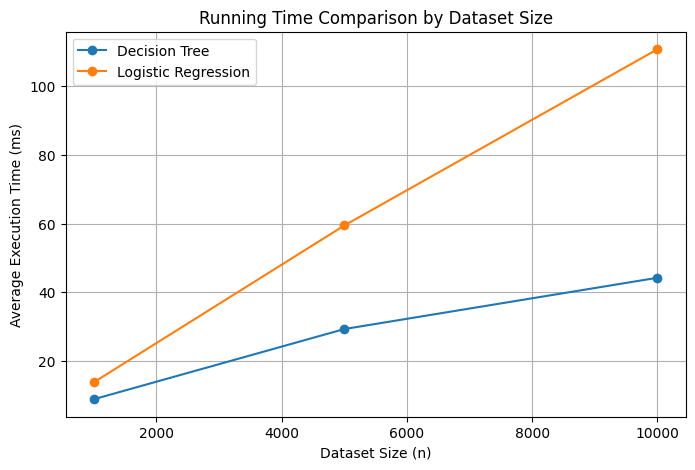

In [41]:
dt_plot = average_results[average_results["Algorithm"] == "Decision Tree"]
lr_plot = average_results[average_results["Algorithm"] == "Logistic Regression"]

plt.figure(figsize=(8, 5))
plt.plot(dt_plot["Dataset Size"], dt_plot["Execution Time (ms)"], marker="o", label="Decision Tree")
plt.plot(lr_plot["Dataset Size"], lr_plot["Execution Time (ms)"], marker="o", label="Logistic Regression")
plt.xlabel("Dataset Size (n)")
plt.ylabel("Average Execution Time (ms)")
plt.title("Running Time Comparison by Dataset Size")
plt.legend()
plt.grid(True)
plt.show()

## 14. Accuracy Comparison Diagram

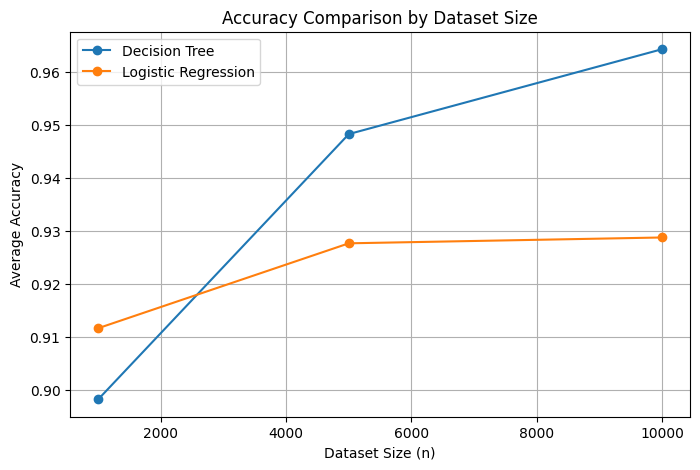

In [42]:
dt_acc_plot = average_results[average_results["Algorithm"] == "Decision Tree"]
lr_acc_plot = average_results[average_results["Algorithm"] == "Logistic Regression"]

plt.figure(figsize=(8, 5))
plt.plot(dt_acc_plot["Dataset Size"], dt_acc_plot["Accuracy"], marker="o", label="Decision Tree")
plt.plot(lr_acc_plot["Dataset Size"], lr_acc_plot["Accuracy"], marker="o", label="Logistic Regression")
plt.xlabel("Dataset Size (n)")
plt.ylabel("Average Accuracy")
plt.title("Accuracy Comparison by Dataset Size")
plt.legend()
plt.grid(True)
plt.show()

## 15. Final Conclusion

In [43]:
dt_overall_accuracy = average_results[average_results["Algorithm"] == "Decision Tree"]["Accuracy"].mean()
lr_overall_accuracy = average_results[average_results["Algorithm"] == "Logistic Regression"]["Accuracy"].mean()
dt_overall_time     = average_results[average_results["Algorithm"] == "Decision Tree"]["Execution Time (ms)"].mean()
lr_overall_time     = average_results[average_results["Algorithm"] == "Logistic Regression"]["Execution Time (ms)"].mean()

print("Overall Decision Tree Accuracy:",        round(dt_overall_accuracy, 4))
print("Overall Logistic Regression Accuracy:",  round(lr_overall_accuracy, 4))
print("Overall Decision Tree Time (ms):",        round(dt_overall_time, 4))
print("Overall Logistic Regression Time (ms):", round(lr_overall_time, 4))

print("\nFinal Conclusion:")
if dt_overall_accuracy > lr_overall_accuracy and dt_overall_time < lr_overall_time:
    print("Decision Tree performed better overall because it achieved higher accuracy and lower execution time.")
elif dt_overall_accuracy > lr_overall_accuracy:
    print("Decision Tree performed better in terms of accuracy.")
elif lr_overall_accuracy > dt_overall_accuracy:
    print("Logistic Regression performed better in terms of accuracy.")
else:
    print("Both algorithms achieved similar accuracy, so execution time should be used for comparison.")

Overall Decision Tree Accuracy: 0.937
Overall Logistic Regression Accuracy: 0.9227
Overall Decision Tree Time (ms): 27.4908
Overall Logistic Regression Time (ms): 61.347

Final Conclusion:
Decision Tree performed better overall because it achieved higher accuracy and lower execution time.
